<a href="https://colab.research.google.com/github/L-jsA/AULAS-GEN---GIT/blob/main/atividadeestat1401.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# 1. Carregar o arquivo
# Certifique-se de que o arquivo foi enviado para o ambiente (ícone da pasta à esquerda)
try:
    df = pd.read_csv('Copy of product.csv')

    # 2. Total de clientes (linhas)
    total_clientes = len(df)

    # 3. Contar quem prefere o "Product B"
    # Usamos o nome correto da coluna: 'Preferred Product'
    preferem_b = len(df[df['Preferred Product'] == 'Product B'])

    # 4. Cálculo da probabilidade
    probabilidade_b = preferem_b / total_clientes

    print(f"Total de clientes: {total_clientes}")
    print(f"Clientes que preferem o Produto B: {preferem_b}")
    print(f"Probabilidade de preferir o Produto B: {probabilidade_b:.2f}")

    if probabilidade_b == 0.50:
        print("\nResposta do PDF: B) 0,50")

except FileNotFoundError:
    print("Erro: O arquivo 'Copy of product.csv' não foi encontrado. Faça o upload no painel lateral.")
except KeyError:
    print(f"Erro: Nome da coluna incorreto. As colunas disponíveis são: {list(df.columns)}")

Total de clientes: 12
Clientes que preferem o Produto B: 6
Probabilidade de preferir o Produto B: 0.50

Resposta do PDF: B) 0,50


In [ ]:
# Dados do problema
total_homens = 6
homens_preferem_A = 4

# Cálculo da probabilidade
probabilidade = homens_preferem_A / total_homens

print(f"A probabilidade de um homem preferir o Produto A é: {probabilidade:.2f}")
# Resultado: 0.67

A probabilidade de um homem preferir o Produto A é: 0.67


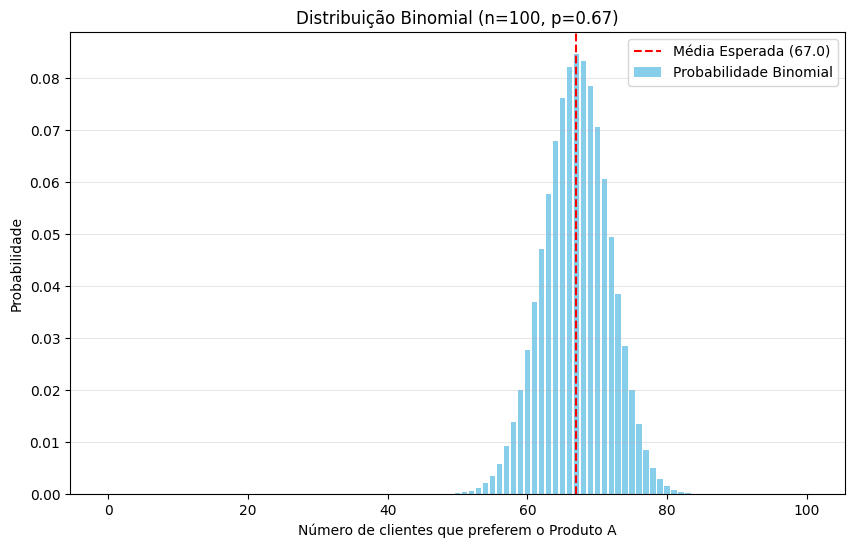

A probabilidade de exatos 70 clientes preferirem o Produto A é: 0.0706


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parâmetros da distribuição
n = 100          # Número total de tentativas (clientes)
p = 0.67         # Probabilidade de sucesso (preferir o Produto A, conforme calculado anteriormente)

# 1. Gerar o intervalo de clientes (de 0 a 100)
x = np.arange(0, n + 1)

# 2. Calcular a Função de Massa de Probabilidade (PMF) para cada valor de x
probabilidades = binom.pmf(x, n, p)

# 3. Criar o gráfico
plt.figure(figsize=(10, 6))
plt.bar(x, probabilidades, color='skyblue', label='Probabilidade Binomial')

# Destacar a média (valor esperado)
media = n * p
plt.axvline(media, color='red', linestyle='--', label=f'Média Esperada ({media})')

plt.title(f'Distribuição Binomial (n={n}, p={p})')
plt.xlabel('Número de clientes que preferem o Produto A')
plt.ylabel('Probabilidade')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Exemplo: Qual a probabilidade de exatamente 70 clientes preferirem o Produto A?
prob_70 = binom.pmf(70, n, p)
print(f"A probabilidade de exatos 70 clientes preferirem o Produto A é: {prob_70:.4f}")

In [ ]:
import pandas as pd
import statsmodels.stats.proportion as prop

# 1. Carregar o arquivo
df = pd.read_csv('Copy of product.csv')

# 2. Definir os valores para o cálculo
total_clientes = len(df)
preferem_a = len(df[df['Preferred Product'] == 'Product A'])

# 3. Calcular o Intervalo de Confiança de 95%
# O método 'normal' é o padrão para o cálculo Z (Wald)
ci_low, ci_high = prop.proportion_confint(preferem_a, total_clientes, alpha=0.05, method='normal')

print(f"Total de clientes: {total_clientes}")
print(f"Clientes que preferem o Produto A: {preferem_a}")
print(f"Intervalo de Confiança (95%): ({ci_low:.2f}, {ci_high:.2f})")

# Validação com a alternativa do PDF
if round(ci_low, 2) == 0.22 and round(ci_high, 2) == 0.78:
    print("\nResposta do PDF confirmada: B) (0,22, 0,78)")

Total de clientes: 12
Clientes que preferem o Produto A: 6
Intervalo de Confiança (95%): (0.22, 0.78)

Resposta do PDF confirmada: B) (0,22, 0,78)


In [ ]:
# Etapa 2


import pandas as pd
import numpy as np
from scipy import stats

try:
    df = pd.read_csv('Copy of product.csv')
    print("Arquivo carregado com sucesso!")
    # Mostra a tabela de contingência real do arquivo para conferir com o PDF
    print(pd.crosstab(df['Gender'], df['Preferred Product']))
except FileNotFoundError:
    print("Arquivo product.csv não encontrado. Usando dados manuais do PDF.")

observado = np.array([[2, 4], [4, 2]])
esperado = np.array([[3, 3], [3, 3]])

# CORREÇÃO 1: Em Python, elevar ao quadrado é **2 (o Qui-Quadrado exige o quadrado)
calculo_celulas = ((observado - esperado)**2) / esperado
qui_quadrado_manual = np.sum(calculo_celulas)

p_valor = 1 - stats.chi2.cdf(qui_quadrado_manual, df=1)

print("\n" + "=" * 30)
print("RESULTADOS DA ETAPA 2")
# CORREÇÃO 2: Adicionado o asterisco (*) para repetir a linha
print("=" * 30)
print(f"Estatística Qui-Quadrado: {qui_quadrado_manual:.2f}")
print(f"Valor de p: {p_valor:.4f}")

Arquivo carregado com sucesso!
Preferred Product  Product A  Product B
Gender                                 
Female                     2          4
Male                       4          2

RESULTADOS DA ETAPA 2
Estatística Qui-Quadrado: 1.33
Valor de p: 0.2482


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Etapa 3

# Etapa 3: Executando o Teste Qui-Quadrado Automatizado
# Carregar os dados
df = pd.read_csv("/content/Copy of product.csv")
contingency_table = pd.crosstab(df["Gender"], df["Preferred Product"])

# Cálculo sem correção de Yates
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table, correction=False)

print(f"Resposta Exercício 1 - Estatística Qui-Quadrado: {chi2_stat:.2f}")

# Cálculo sem correção de Yates
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table, correction=False)

print(f"Resposta Exercício 2 - Valor de p: {p_value:.4f}")

# Cálculo COM correção de Yates (correction=True)
chi2_stat_yates, p_value_yates, dof_yates, expected_yates = chi2_contingency(contingency_table, correction=True)

print(f"Resposta Exercício 3 - Estatística com Yates: {chi2_stat_yates:.2f}")



Resposta Exercício 1 - Estatística Qui-Quadrado: 1.33
Resposta Exercício 2 - Valor de p: 0.2482
Resposta Exercício 3 - Estatística com Yates: 0.33


In [ ]:
# Etapa 4: Interpretando os Resultados
# --- PRINT FINAL DOS RESULTADOS ---
print("--- RESUMO DA ANÁLISE ESTATÍSTICA ---")
print(f"1. Qui-Quadrado (Automático): {chi2_stat:.2f}")
print(f"2. Valor de p (Automático): {p_value:.4f}")
print(f"3. Qui-Quadrado (Com Correção de Yates): {chi2_stat_yates:.2f}")
print(f"4. Valor de p (Com Correção de Yates): {p_value_yates:.4f}")
print("-------------------------------------")
print("Conclusão: Em ambos os casos (com ou sem Yates), o p-valor é maior que 0.05.")
print("Portanto, falhamos em rejeitar a hipótese nula: o gênero não influencia a preferência.")

--- RESUMO DA ANÁLISE ESTATÍSTICA ---
1. Qui-Quadrado (Automático): 1.33
2. Valor de p (Automático): 0.2482
3. Qui-Quadrado (Com Correção de Yates): 0.33
4. Valor de p (Com Correção de Yates): 0.5637
-------------------------------------
Conclusão: Em ambos os casos (com ou sem Yates), o p-valor é maior que 0.05.
Portanto, falhamos em rejeitar a hipótese nula: o gênero não influencia a preferência.
